In [42]:
#imports
import numpy as np
import pandas as pd
from sklearn import tree

input_file = "/content/drive/MyDrive/Colab Notebooks/Card 13/emails/PastHires.csv" #Faz a leitura do arquivo o arquivo dentro da pasta
df = pd.read_csv(input_file, header = 0) #faz a leitura do csv e joga pra um DF

In [43]:
df.head() # olha o inicio do DF

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,Y,4,BS,N,N,Y
1,0,N,0,BS,Y,Y,Y
2,7,N,6,BS,N,N,N
3,2,Y,1,MS,Y,N,Y
4,20,N,2,PhD,Y,N,N


In [44]:
d = {'Y': 1, 'N': 0} #dicionario pra Y ser 1 e N ser 0
df['Hired'] = df['Hired'].map(d) #Cjoga a coluna hired que tem o Y e N pra 1 e 0
df['Employed?'] = df['Employed?'].map(d) #msm coisa pra essa
df['Top-tier school'] = df['Top-tier school'].map(d) #msm coisa pra essa
df['Interned'] = df['Interned'].map(d) #msm coisa com outra coluna
d = {'BS': 0, 'MS': 1, 'PhD': 2} #se tem bs 0 ms 1 e phd 2 igual com o Y e N antes
df['Level of Education'] = df['Level of Education'].map(d) #msm coisa de antes agr pros 3 de antes
df.head()


,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,1,4,0,0,0,1
1,0,0,0,0,1,1,1
2,7,0,6,0,0,0,0
3,2,1,1,1,1,0,1
4,20,0,2,2,1,0,0


In [45]:
features = list(df.columns[:6])  #joga as 6 primeiras colunas do DF pra lista
features #printa

['Years Experience',
 'Employed?',
 'Previous employers',
 'Level of Education',
 'Top-tier school',
 'Interned']

In [46]:
y = df["Hired"] #define como vamos prever se a pessoa foi contratada ou nao
X = df[features] #entradas do modelo
clf = tree.DecisionTreeClassifier() #faz o modelo da arvore
clf = clf.fit(X, y) #treina

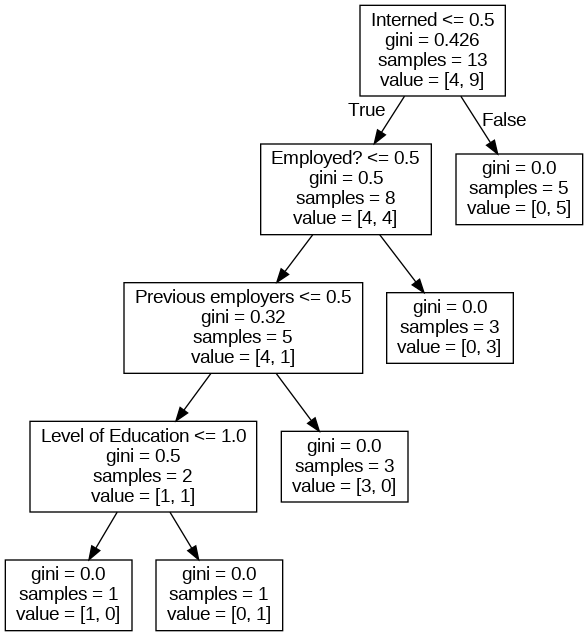

In [47]:
#novos imports
from IPython.display import Image
from io import StringIO
import pydot

dot_data = StringIO() #Aqui armezena o grafico com esse buffer de texto
tree.export_graphviz(clf, out_file = dot_data, feature_names = features) #Faz o formato visual

graph = pydot.graph_from_dot_data(dot_data.getvalue()) #Pega o texto e transforma para grafico
Image(graph[0].create_png()) #Faz uma imagem

In [49]:
#import
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators = 10) # Aqui é criado 10 arvores de decisao
clf = clf.fit(X, y) #faz o processo de treinamento

#exibi os prints
print(clf.predict([[10, 1, 4, 0, 0, 0]]))
print(clf.predict([[10, 0, 4, 0, 0, 0]]))

[1]
[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
